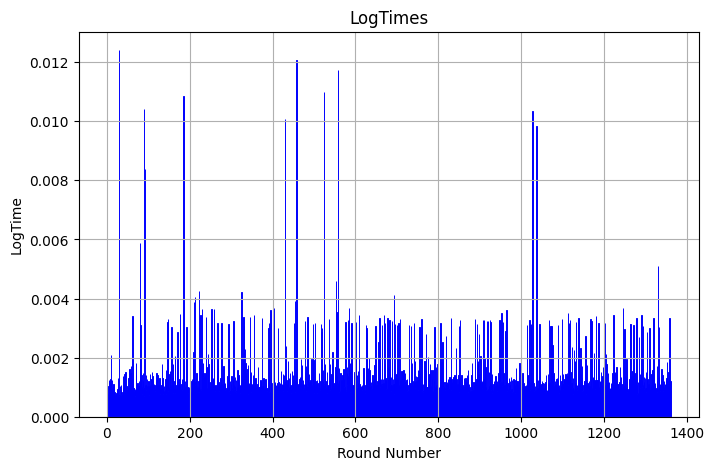

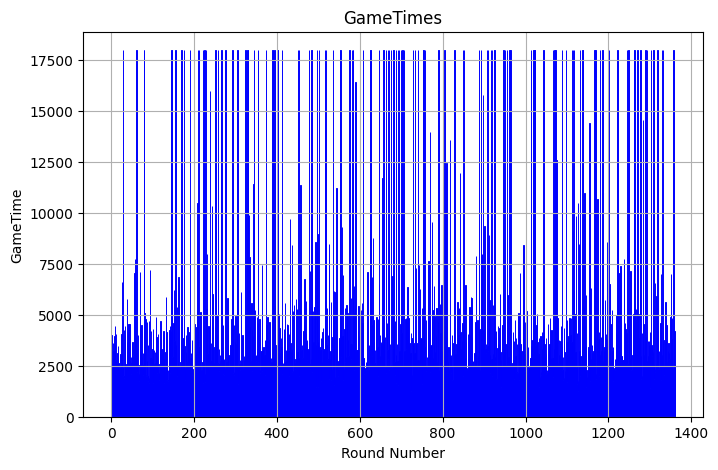

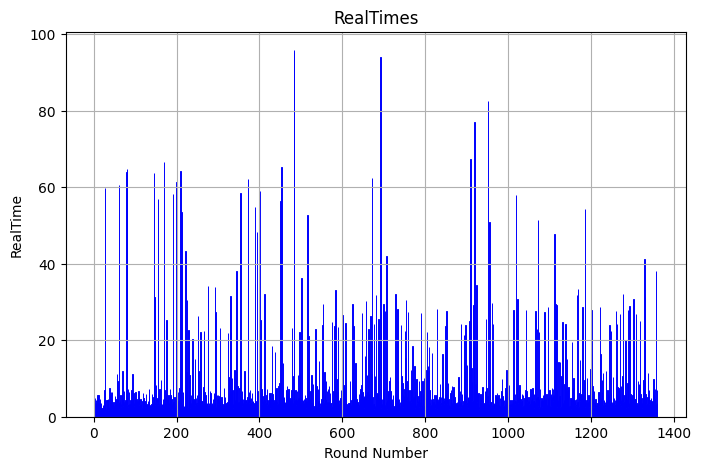

In [18]:
import json
import os
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output

# Path to your log file
folder_path = "..\\..\\..\\Saved\\Data"
files = os.listdir(folder_path)

if files:
    firstfile = os.path.join(folder_path, files[0])  # Ensure full path
    print(f"Opening file: {firstfile}")

    with open(firstfile, 'r') as file:
        rounds = []
        for line in file:
            # Try to load each line as a separate JSON object
            try:
                json_obj = json.loads(line.strip())  # Strip any extra whitespace or newlines
                rounds.append(json_obj)
            except json.JSONDecodeError as e:
                print(f"Error parsing line: {line}. Error: {e}")

        roundNumbers = []
        savingLastLogTimes = []
        roundGameTimes = []
        roundRealTimes = []
        roundTicks = []
        print("Parsed data:")
        for round_data in rounds:
            roundNumbers.append(round_data['RoundNumber'])
            savingLastLogTimes.append(round_data['SavingLastLogTime'])
            roundGameTime = 0
            roundRealTime = 0
            roundTick = 0
            for log in round_data['Logs']:
                roundGameTime += log['GameTime']
                roundRealTime += log['RealTime']
                roundTick += log['TickCount']
            roundGameTimes.append(roundGameTime)
            roundRealTimes.append(roundRealTime)
            roundTicks.append(roundGameTime)
            

         # Clear previous plot
        clear_output(wait=True)

        #log times
        plt.figure(figsize=(8, 5))
        plt.bar(roundNumbers, savingLastLogTimes, width=1, edgecolor="blue", linewidth=0.7)
        plt.xlabel("Round Number")
        plt.ylabel("LogTime")
        plt.title("LogTimes")
        plt.grid(True)
        plt.show()

        # gameTimes
        plt.figure(figsize=(8, 5))
        plt.bar(roundNumbers, roundGameTimes, width=1, edgecolor="blue", linewidth=0.7)
        plt.xlabel("Round Number")
        plt.ylabel("GameTime")
        plt.title("GameTimes")
        plt.grid(True)
        plt.show()

        # Realtimes
        plt.figure(figsize=(8, 5))
        plt.bar(roundNumbers, roundRealTimes, width=1, edgecolor="blue", linewidth=0.7)
        plt.xlabel("Round Number")
        plt.ylabel("RealTime")
        plt.title("RealTimes")
        plt.grid(True)
        plt.show()
else:
    print("No files found in the directory!")